# Galaxy Classification for Next-Generation Astronomical Surveys
### DATA7903 Capstone — Exploration Notebook

Exploratory analysis of SDSS photometric and spectroscopic data, merged with Galaxy Zoo vote labels, to build a labelled dataset for galaxy morphology classification.

## Table of Contents

1. [Setup](#1-setup)
2. [Imports](#2-imports)
3. [Galaxy Zoo Labels](#3-galaxy-zoo-labels)
4. [Label Distribution & Vote Analysis](#4-label-distribution--vote-analysis)
5. [Load & Merge Feature Data (SDSS)](#5-load--merge-feature-data-sdss)
6. [Column Selection](#6-column-selection)
7. [Join Features with Labels](#7-join-features-with-labels)
8. [Exploratory Data Analysis](#8-exploratory-data-analysis)
9. [Data Cleaning & Preprocessing](#9-data-cleaning--preprocessing)
10. [Feature Importance & Reduction](#10-feature-importance--reduction)


## 1. Setup

Install all required packages from `requirements.txt` into the active kernel.

In [1]:
import sys, subprocess

proc = subprocess.Popen(
    [sys.executable, "-m", "pip", "install", "-r", "../requirements.txt"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)
for line in proc.stdout:
    print(line, end="", flush=True)
proc.wait()
print("Done." if proc.returncode == 0 else f"pip exited with code {proc.returncode}")

  Using cached sciserver-2.2.0-py3-none-any.whl
Done.


## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math

## 3. Galaxy Zoo Labels

Load the Galaxy Zoo vote CSV and derive a `galaxy_class` label (Elliptical / Spiral / Merger) for each object, then one-hot-encode the labels.

In [ ]:

# ---- Load CSV ----
 file_path = "..\\..\\input\\tables\\A_Zoo_Votes.csv"   

# ---- Compute class scores ----
df["Class_Ell"] = df["p_el"]

df["Class_Spiral"] = (
    df["p_cw"] +
    df["p_acw"] +
    df["p_edge"]
)

df["Class_Merger"] = df["p_mg"]

# ---- Determine winning class ----
df["galaxy_class"] = df[[
    "Class_Ell",
    "Class_Spiral",
    "Class_Merger"
]].idxmax(axis=1)

# ---- Optional: convert names to simple labels ----
class_map = {
    "Class_Ell": "Elliptical",
    "Class_Spiral": "Spiral",
    "Class_Merger": "Merger"
}

df["galaxy_class"] = df["galaxy_class"].map(class_map)

df_y_class = df[["objid","specobjid","galaxy_class"]]


## 4. Label Distribution & Vote Analysis

One-hot-encode `galaxy_class`, summarise class counts / percentages, and visualise vote distributions per class.

In [4]:
df_y_onehot = pd.get_dummies(df_y_class)

df_y = df_y_onehot.drop(columns=["objid", "specobjid"])
# Basic info
print("Dataset shape:")
print(df_y.shape)

print("\nColumn names:")
print(df_y.columns.tolist())


# ---- Class counts ----
class_counts = df_y.sum()

print("\nClass Counts:")
print(class_counts)


# ---- Class percentages ----
class_percent = class_counts / len(df_y) * 100

print("\nClass Percentages:")
print(class_percent.round(2))


# ---- Summary statistics ----
print("\nSummary Statistics:")
display(df_y.describe())


# ---- Check one-hot integrity ----
row_sums = df_y.sum(axis=1)

print("\nRows with invalid one-hot encoding (should equal 1):")
print((row_sums != 1).sum())


# ---- Distribution table ----
summary_table = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percent
})

print("\nClass Distribution Summary:")
display(summary_table)

Dataset shape:
(482114, 3)

Column names:
['galaxy_class_Elliptical', 'galaxy_class_Merger', 'galaxy_class_Spiral']

Class Counts:
galaxy_class_Elliptical    281880
galaxy_class_Merger          8393
galaxy_class_Spiral        191841
dtype: int64

Class Percentages:
galaxy_class_Elliptical    58.47
galaxy_class_Merger         1.74
galaxy_class_Spiral        39.79
dtype: float64

Summary Statistics:


,galaxy_class_Elliptical,galaxy_class_Merger,galaxy_class_Spiral
count,482114,482114,482114
unique,2,2,2
top,True,False,False
freq,281880,473721,290273



Rows with invalid one-hot encoding (should equal 1):
0

Class Distribution Summary:


,Count,Percentage (%)
galaxy_class_Elliptical,281880,58.467499
galaxy_class_Merger,8393,1.740875
galaxy_class_Spiral,191841,39.791626


,total_nvote_tot
galaxy_class,
Elliptical,22928756
Spiral,13650676
Merger,517113


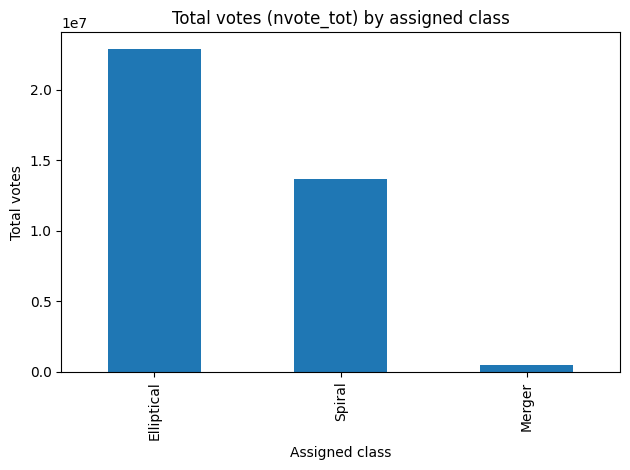

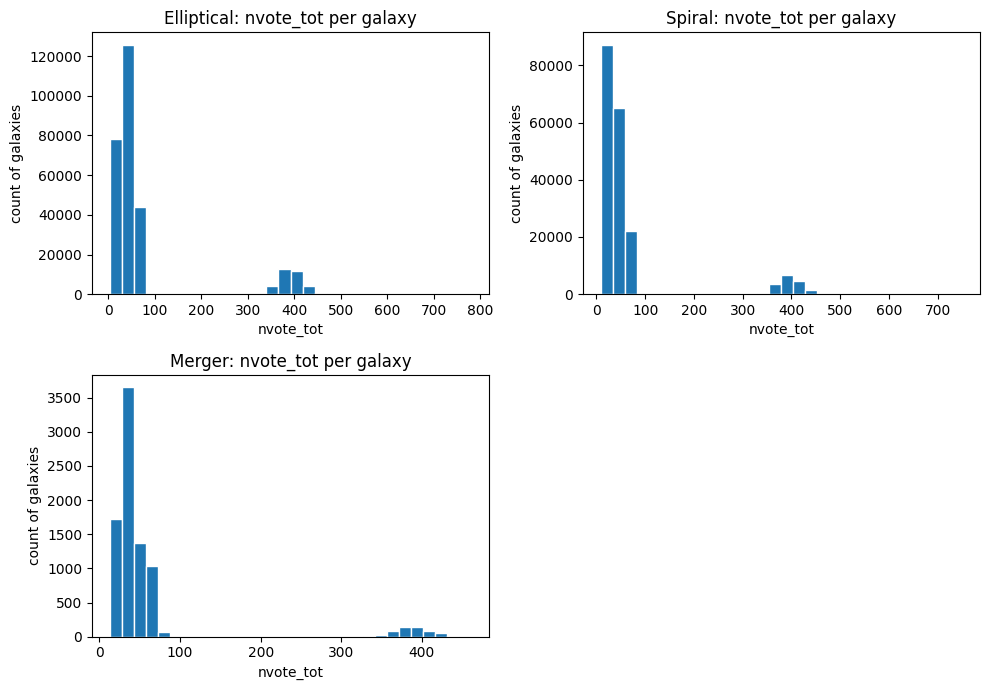

In [5]:
# --- Safety: make sure votes are numeric ---
for c in ["nvote_tot", "nvote_std", "nvote_mr1", "nvote_mr2", "nvote_mon"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# --- 1) Total votes per assigned class (using nvote_tot) ---
votes_by_class = (
    df.groupby("galaxy_class")["nvote_tot"]
      .sum()
      .sort_values(ascending=False)
)

display(votes_by_class.to_frame("total_nvote_tot"))

# Bar chart: total votes per class
ax = votes_by_class.plot(kind="bar")
ax.set_title("Total votes (nvote_tot) by assigned class")
ax.set_xlabel("Assigned class")
ax.set_ylabel("Total votes")
plt.tight_layout()
plt.show()

# --- 2) Histogram: votes-per-galaxy distribution, split by class ---
classes = ["Elliptical", "Spiral", "Merger"]
cols = 2
rows = math.ceil(len(classes) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(10, 3.5 * rows), squeeze=False)
axes_flat = axes.ravel()

for i, cls in enumerate(classes):
    ax = axes_flat[i]
    vals = df.loc[df["galaxy_class"] == cls, "nvote_tot"].dropna()

    if len(vals) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_title(cls)
        ax.axis("off")
        continue

    ax.hist(vals, bins=30, edgecolor="white")
    ax.set_title(f"{cls}: nvote_tot per galaxy")
    ax.set_xlabel("nvote_tot")
    ax.set_ylabel("count of galaxies")

# hide unused subplot if odd number of classes
for j in range(len(classes), len(axes_flat)):
    axes_flat[j].axis("off")

plt.tight_layout()
plt.show()

## 5. Load & Merge Feature Data (SDSS)

Load the vertical-fragment CSVs downloaded from CasJobs (`PHOTO_VF*` and `SPEC_VF*`) and merge them into a single spine-keyed `df_photo` and `df_spec` DataFrame.

In [ ]:

CASJOBS_DIR = Path("../../input/tables")      # raw downloaded CasJobs CSVs
RESULTS_DIR = Path("../../results/evaluation") # notebook analysis outputs
RESULTS_DIR.mkdir(exist_ok=True)

OBJID_FILE = CASJOBS_DIR / "DR19_objID_List_apmartin.csv"

KEY = "objID"  # change to "objid" if your CSV uses lowercase

def load_spine(objid_file: Path, key: str) -> pd.DataFrame:
    spine = pd.read_csv(objid_file)
    if key not in spine.columns:
        if key.lower() in spine.columns:
            key = key.lower()
        else:
            raise ValueError(f"Could not find '{key}' in {objid_file.name}. Columns={spine.columns.tolist()}")

    spine = spine[[key]].copy()
    spine[key] = pd.to_numeric(spine[key], errors="coerce").astype("Int64")
    spine = spine.dropna(subset=[key]).drop_duplicates(subset=[key])
    spine[key] = spine[key].astype("int64")
    spine = spine.rename(columns={key: KEY})
    return spine

def merge_vfs(spine: pd.DataFrame, pattern: str) -> pd.DataFrame:
    # pattern examples: "PHOTO_VF", "SPEC_VF"
    vf_files = sorted([p for p in CASJOBS_DIR.glob("*.csv") if pattern in p.name.upper()])
    print(f"\n[{pattern}] Spine rows: {len(spine):,}")
    print(f"[{pattern}] VF files: {len(vf_files)}")

    out = spine.copy()

    for p in vf_files:
        part = pd.read_csv(p)

        if KEY not in part.columns:
            cols_lower = {c.lower(): c for c in part.columns}
            accepted = {KEY.lower(), "bestobjid"}

            hit = next((k for k in accepted if k in cols_lower), None)
            if hit is None:
                print(f"Skipping {p.name} (no {KEY}/{KEY.lower()} or bestObjID)")
                continue

            part = part.rename(columns={cols_lower[hit]: KEY})

        part[KEY] = pd.to_numeric(part[KEY], errors="coerce").astype("Int64")
        part = part.dropna(subset=[KEY]).drop_duplicates(subset=[KEY])
        part[KEY] = part[KEY].astype("int64")

        overlap = set(out.columns).intersection(part.columns) - {KEY}
        if overlap:
            part = part.drop(columns=list(overlap))

        out = out.merge(part, on=KEY, how="left")
        print(f"Merged {p.name:45s} -> shape={out.shape}")

    return out

# ---- Run ----
spine = load_spine(OBJID_FILE, KEY)

df_photo = merge_vfs(spine, "PHOTO_VF")
display(df_photo.head())

df_spec = merge_vfs(spine, "SPEC_VF")
display(df_spec.head())

df_all = df_photo.merge(df_spec, on=KEY, how="left", suffixes=("", "_spec"))
print("\nCombined df_all shape:", df_all.shape)
display(df_all.head())



[PHOTO_VF] Spine rows: 481,403
[PHOTO_VF] VF files: 49
Merged DATA7901_DR19_Photo_VF01.csv                  -> shape=(481403, 11)
Merged DATA7901_DR19_Photo_VF02.csv                  -> shape=(481403, 21)
Merged DATA7901_DR19_Photo_VF03.csv                  -> shape=(481403, 31)
Merged DATA7901_DR19_Photo_VF04.csv                  -> shape=(481403, 41)
Merged DATA7901_DR19_Photo_VF05.csv                  -> shape=(481403, 51)
Merged DATA7901_DR19_Photo_VF06.csv                  -> shape=(481403, 61)
Merged DATA7901_DR19_Photo_VF07.csv                  -> shape=(481403, 71)
Merged DATA7901_DR19_Photo_VF08.csv                  -> shape=(481403, 81)
Merged DATA7901_DR19_Photo_VF09.csv                  -> shape=(481403, 91)
Merged DATA7901_DR19_Photo_VF10.csv                  -> shape=(481403, 101)
Merged DATA7901_DR19_Photo_VF11.csv                  -> shape=(481403, 111)
Merged DATA7901_DR19_Photo_VF12.csv                  -> shape=(481403, 121)
Merged DATA7901_DR19_Photo_VF13.csv      

,objID,skyVersion,run,rerun,camcol,field,obj,mode,nChild,type,...,u_u,u_g,u_r,u_i,u_z,uErr_u,uErr_g,uErr_r,uErr_i,uErr_z
0,1237648702967447657,2,752,301,1,281,105,1,0,3,...,0.020366,-0.003487,-0.000626,0.002416,-0.009903,0.028153,0.005922,0.005947,0.007516,0.025784
1,1237648702973214844,2,752,301,1,369,124,1,0,3,...,-0.024778,0.146676,0.116794,0.099072,0.093345,0.082598,0.009068,0.005680,0.005778,0.014822
2,1237648702973542688,2,752,301,1,374,288,1,0,3,...,-0.011698,-0.020276,-0.023205,-0.019975,-0.029470,0.027522,0.009476,0.009318,0.009596,0.012249
3,1237648702974197818,2,752,301,1,384,58,1,0,3,...,-0.094689,-0.078966,-0.084366,-0.098905,-0.101679,0.027043,0.005075,0.004428,0.004965,0.014131
4,1237648702975836378,2,752,301,1,409,218,1,0,3,...,0.016581,0.009464,0.018796,0.017720,0.006038,0.043055,0.004972,0.003105,0.003160,0.008023



[SPEC_VF] Spine rows: 481,403
[SPEC_VF] VF files: 18
Merged DATA7901_DR19_Spec_VF01.csv                   -> shape=(481403, 12)
Merged DATA7901_DR19_Spec_VF02.csv                   -> shape=(481403, 22)
Merged DATA7901_DR19_Spec_VF03.csv                   -> shape=(481403, 32)
Merged DATA7901_DR19_Spec_VF04.csv                   -> shape=(481403, 42)
Merged DATA7901_DR19_Spec_VF05.csv                   -> shape=(481403, 52)
Merged DATA7901_DR19_Spec_VF06.csv                   -> shape=(481403, 62)
Merged DATA7901_DR19_Spec_VF07.csv                   -> shape=(481403, 72)
Merged DATA7901_DR19_Spec_VF08.csv                   -> shape=(481403, 82)
Merged DATA7901_DR19_Spec_VF09.csv                   -> shape=(481403, 92)
Merged DATA7901_DR19_Spec_VF10.csv                   -> shape=(481403, 102)
Merged DATA7901_DR19_Spec_VF11.csv                   -> shape=(481403, 112)
Merged DATA7901_DR19_Spec_VF12.csv                   -> shape=(481403, 122)
Merged DATA7901_DR19_Spec_VF13.csv         

,objID,specObjID,fluxObjID,targetObjID,plateID,plate,mjd,fiberID,sciencePrimary,sdssPrimary,...,elodieTEff,elodieLogG,elodieFeH,elodieZ,elodieZErr,elodieZModelErr,elodieRChi2,elodieDOF,htmID,loadVersion
0,1237648702967447657,324260581114669056,1237648702967447657,284705347403904,324259206725134336,288,52000,5,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0,11009215543435,5067
1,1237648702973214844,332155624106256384,1237648702973214844,284705353171047,332140505821374464,295,51985,55,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0,11033342889383,5067
2,1237648702973542688,333334300554455040,1237648702973542688,284705353498755,333266405711439872,296,51984,247,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0,11033428317191,5067
3,1237648702974197818,334460474919774208,1237648702974197818,284705354154017,334392305198852096,297,51959,248,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0,11030407223617,5067
4,1237648702975836378,336721615750457344,1237648702975836378,284705355792520,336644100180699136,299,51671,282,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0,11153436339565,5067



Combined df_all shape: (481403, 655)


,objID,skyVersion,run,rerun,camcol,field,obj,mode,nChild,type,...,elodieTEff,elodieLogG,elodieFeH,elodieZ,elodieZErr,elodieZModelErr,elodieRChi2,elodieDOF,htmID_spec,loadVersion_spec
0,1237648702967447657,2,752,301,1,281,105,1,0,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0,11009215543435,5067
1,1237648702973214844,2,752,301,1,369,124,1,0,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0,11033342889383,5067
2,1237648702973542688,2,752,301,1,374,288,1,0,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0,11033428317191,5067
3,1237648702974197818,2,752,301,1,384,58,1,0,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0,11030407223617,5067
4,1237648702975836378,2,752,301,1,409,218,1,0,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0,11153436339565,5067


## 6. Column Selection

Drop metadata, survey-flag, and duplicate positional columns from `df_photo` and `df_spec` that are not useful as model features.

In [7]:
Columns_to_remove_photo = [
"thingId", "fieldID", "parentID", "htmID", "balkanId",
"skyVersion", "run", "rerun", "camcol", "field", "obj", "loadVersion", "resolveStatus",
"flags", "insideMask", "flags_u", "flags_g", "flags_r", "flags_i", "flags_z",
"calibStatus_u", "calibStatus_g", "calibStatus_r", "calibStatus_i", "calibStatus_z",
"cloudCam_u", "cloudCam_g", "cloudCam_r", "cloudCam_i", "cloudCam_z",
"type", "type_u", "type_g", "type_r", "type_i", "type_z",
"probPSF", "probPSF_u", "probPSF_g", "probPSF_r", "probPSF_i", "probPSF_z",
"nObserve", "nDetect", "nEdge", "score", "mjd"
]

Columns_to_remove_spec = [
"fluxObjID", "targetObjID", "plateID",
"thing_id_targeting", "thing_id", "htmID",
"plate", "fiberID", "tile", "designID", "mjd", "spectrographID",
"sciencePrimary", "sdssPrimary", "legacyPrimary", "seguePrimary",
"segue1Primary", "segue2Primary", "bossPrimary", "bossSpecObjID",
"firstRelease", "survey", "instrument", "programname", "chunk",
"platerun", "run1d", "run2d", "loadVersion",
"legacy_target1", "legacy_target2", "special_target1", "special_target2",
"segue1_target1", "segue1_target2", "segue2_target1", "segue2_target2",
"boss_target1", "eboss_target0", "eboss_target1", "eboss_target2",
"eboss_target_id", "ancillary_target1", "ancillary_target2",
"primTarget", "secTarget",
"sourceType", "targetType", "tFile",
"elodieFileName", "elodieObject", "elodieSpType",
"tColumn_0", "tColumn_1", "tColumn_2", "tColumn_3", "tColumn_4",
"tColumn_5", "tColumn_6", "tColumn_7", "tColumn_8", "tColumn_9",
"ra", "dec", "cx", "cy", "cz", "xFocal", "yFocal",
"z_person", "class_person", "comments_person",
"class", "subClass", "class_noqso", "subClass_noqso",
"img"
]

df_photo = df_photo.drop(columns=Columns_to_remove_photo, errors="ignore")
df_spec = df_spec.drop(columns=Columns_to_remove_spec, errors="ignore")

## 7. Join Features with Labels

Inner-join `df_photo` and `df_spec` on `objID` / `specObjID`, normalise column names to lowercase, then merge the result with the Galaxy Zoo one-hot label table (`df_y_onehot`) to produce `df_fullset`.

In [8]:
# Both df_photo and df_spec have objID and specObjID — join on both
print(f"df_photo rows: {len(df_photo):,}  |  df_spec rows: {len(df_spec):,}")
print(f"Matching objID values:     {df_photo['objID'].isin(df_spec['objID']).sum():,}")
print(f"Matching specObjID values: {df_photo['specObjID'].isin(df_spec['specObjID']).sum():,}")

df_joined = df_photo.merge(
    df_spec,
    how="inner",
    on=["objID", "specObjID"]
)

# Normalise all column names to lowercase
df_joined.columns = df_joined.columns.str.lower()

print(f"\ndf_joined shape: {df_joined.shape}")
display(df_joined.head(3))

df_photo rows: 481,403  |  df_spec rows: 481,403
Matching objID values:     481,403
Matching specObjID values: 481,000

df_joined shape: (481000, 538)


,objid,mode,nchild,clean,ra,dec,cx,cy,cz,raerr,...,sn2_i,elodiebv,elodieteff,elodielogg,elodiefeh,elodiez,elodiezerr,elodiezmodelerr,elodierchi2,elodiedof
0,1237648702967447657,1,0,1,185.635350,-1.209897,-0.994945,-0.098175,-0.021115,0.038588,...,24.2702,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,1237648702973214844,1,0,1,198.784959,-1.053675,-0.946574,-0.321963,-0.018389,0.008410,...,18.3799,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,1237648702973542688,1,0,1,199.583391,-1.091676,-0.941984,-0.335118,-0.019052,0.004531,...,23.5779,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [9]:
df_y_onehot.columns = df_y_onehot.columns.str.lower()
df_y_onehot = df_y_onehot.loc[:, ~df_y_onehot.columns.duplicated()]

print(f"df_joined rows:   {len(df_joined):,}")
print(f"df_y_onehot rows: {len(df_y_onehot):,}")
print(f"Matching objid:     {df_joined['objid'].isin(df_y_onehot['objid']).sum():,}")
print(f"Matching specobjid: {df_joined['specobjid'].isin(df_y_onehot['specobjid']).sum():,}")

df_fullset = df_joined.merge(
    df_y_onehot[["objid", "specobjid", "galaxy_class_elliptical", "galaxy_class_merger", "galaxy_class_spiral"]],
    on=["objid", "specobjid"],
    how="inner"
)

print(f"\ndf_fullset shape: {df_fullset.shape}")
display(df_fullset.head(3))

df_joined rows:   481,000
df_y_onehot rows: 482,114
Matching objid:     481,000
Matching specobjid: 444,168


C:\Users\apmar\AppData\Local\Temp\ipykernel_31740\194896290.py:9: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  df_fullset = df_joined.merge(



df_fullset shape: (444167, 541)


,objid,mode,nchild,clean,ra,dec,cx,cy,cz,raerr,...,elodielogg,elodiefeh,elodiez,elodiezerr,elodiezmodelerr,elodierchi2,elodiedof,galaxy_class_elliptical,galaxy_class_merger,galaxy_class_spiral
0,1237648702967447657,1,0,1,185.635350,-1.209897,-0.994945,-0.098175,-0.021115,0.038588,...,0.0,0.0,0.0,0.0,0.0,0.0,0,False,False,True
1,1237648702983110890,1,0,1,221.371679,-1.185746,-0.750277,-0.660799,-0.020694,0.026107,...,0.0,0.0,0.0,0.0,0.0,0.0,0,False,False,True
2,1237648703508643959,1,0,0,195.448118,-0.796206,-0.963779,-0.266340,-0.013896,0.006838,...,0.0,0.0,0.0,0.0,0.0,0.0,0,False,False,True


In [10]:
# Concatenate objid + specobjid into a single composite string ID and set as index
df_fullset["galaxy_id"] = (
    df_fullset["objid"].astype(str) + "_" + df_fullset["specobjid"].astype(str)
)

# Verify uniqueness before setting as index
n_dupes = df_fullset["galaxy_id"].duplicated().sum()
print(f"Duplicate galaxy_id values: {n_dupes}  (should be 0)")

df_fullset = df_fullset.set_index("galaxy_id").drop(columns=["objid", "specobjid"])

print(f"df_fullset shape: {df_fullset.shape}")
print(f"Index name: {df_fullset.index.name}")
display(df_fullset.head(3))

Duplicate galaxy_id values: 0  (should be 0)
df_fullset shape: (444167, 539)
Index name: galaxy_id


,mode,nchild,clean,ra,dec,cx,cy,cz,raerr,decerr,...,elodielogg,elodiefeh,elodiez,elodiezerr,elodiezmodelerr,elodierchi2,elodiedof,galaxy_class_elliptical,galaxy_class_merger,galaxy_class_spiral
galaxy_id,,,,,,,,,,,,,,,,,,,,,
1237648702967447657_3.2426058111466906e+17,1,0,1,185.635350,-1.209897,-0.994945,-0.098175,-0.021115,0.038588,0.055773,...,0.0,0.0,0.0,0.0,0.0,0.0,0,False,False,True
1237648702983110890_3.468338240401183e+17,1,0,1,221.371679,-1.185746,-0.750277,-0.660799,-0.020694,0.026107,0.010463,...,0.0,0.0,0.0,0.0,0.0,0.0,0,False,False,True
1237648703508643959_3.298911749427958e+17,1,0,0,195.448118,-0.796206,-0.963779,-0.266340,-0.013896,0.006838,0.007152,...,0.0,0.0,0.0,0.0,0.0,0.0,0,False,False,True


## 8. Exploratory Data Analysis

Overview of feature types, missing data, outliers, and distribution anomalies across `df_fullset`.


────────────────────────────────────────────────────────────
  df_fullset   444,167 rows  ×  539 columns
  Memory: 1946.1 MB
────────────────────────────────────────────────────────────


════════════════════════════════════════════════════════════
  8.1  Feature Types
════════════════════════════════════════════════════════════
  Numerical features :   536
  Categorical features:    3

  ── Top 10 Numerical Features (alphabetical) ──


,dtype,nunique,mean,std
mode,int64,1,1.0000,0.0000
nchild,int64,1,0.0000,0.0000
clean,int64,2,0.8145,0.3887
ra,float64,444167,184.6448,57.7334
dec,float64,444167,25.0699,18.7408
cx,float64,444167,-0.5449,0.4680
cy,float64,444167,-0.0699,0.4901
cz,float64,444167,0.4002,0.2806
raerr,float64,444167,0.0168,0.0378
decerr,float64,444167,0.0167,0.0387


  ── Top 10 Categorical Features ──


,dtype,nunique,top_value
galaxy_class_elliptical,bool,2,True
galaxy_class_merger,bool,2,False
galaxy_class_spiral,bool,2,False



════════════════════════════════════════════════════════════
  8.2  Missing Data
════════════════════════════════════════════════════════════
  Columns with any missing : 0
  Columns with > 5% missing: 0
  Columns with >50% missing: 0

  No missing values found.


════════════════════════════════════════════════════════════
  8.3  Outliers  (3 × IQR fence, numeric columns only)
════════════════════════════════════════════════════════════
  Numeric columns with any outliers   : 457
  Numeric columns with >5% outliers   : 72
  Numeric columns with >10% outliers  : 3

  ── Top 10 Columns by Outlier % ──


,outlier_%,min,max,mean
column,,,,
petroraderr_u,20.68,-9.999000e+03,2.254371e+02,-1.531803e+02
fracnsigma_7,12.21,0.000000e+00,6.140000e-02,5.000000e-04
fracnsighi_6,11.01,0.000000e+00,4.180000e-02,5.000000e-04
fracnsiglo_5,9.70,0.000000e+00,6.480000e-02,4.000000e-04
fracnsigma_6,9.69,0.000000e+00,7.570000e-02,8.000000e-04
petrorad_u,9.34,5.200000e-03,2.585635e+02,1.122540e+01
mrrccerr_u,8.45,-9.999000e+03,1.748224e+03,-5.521530e+01
fracnsighi_5,8.35,0.000000e+00,4.990000e-02,8.000000e-04
anyormask,8.30,5.996544e+07,5.347082e+08,2.580995e+08


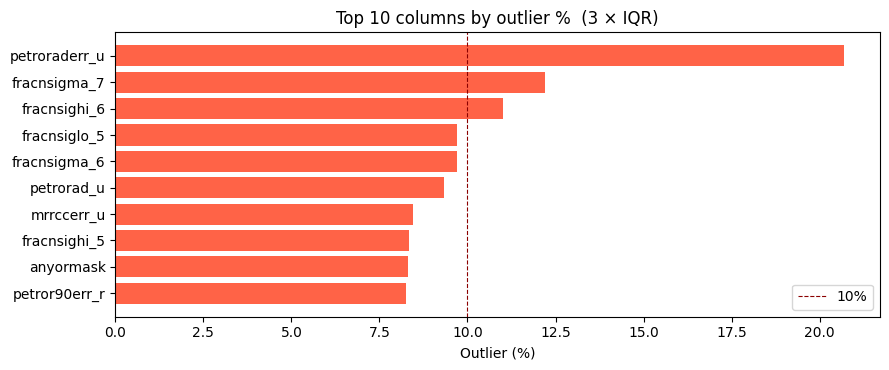


════════════════════════════════════════════════════════════
  8.4  Distribution Skewness  (|skew| > 10 threshold)
════════════════════════════════════════════════════════════
  Numeric columns with |skew| > 10 : 314
  (Note: extreme values like ±333, ±664 typically indicate
   SDSS sentinel fill values (-9999) — replace before modelling)

  ── Top 10 Most Skewed Columns ──


,skewness,min,max
column,,,
mcr4psf_r,-666.5,-9999.00,2.68
modelmagerr_i,-666.4,-9999.00,14.37
err_i,-666.4,-9999.00,14.37
fibermagerr_i,-666.4,-9999.00,5.87
me1psf_r,-666.4,-9999.00,0.44
me2psf_r,-666.4,-9999.00,0.61
sn1_g,666.4,1.09,787044.00
fiber2magerr_i,-666.4,-9999.00,7.60
u_i,-666.4,-9999.00,20.70



════════════════════════════════════════════════════════════
  8.5  Constant & Near-Useless Columns
════════════════════════════════════════════════════════════
  Constant numeric columns (std = 0) : 11
    • mode                                 value = 1.0
    • nchild                               value = 0.0
    • lambdaeff                            value = 5000.0
    • bluefiber                            value = -1.0
    • zoffset                              value = 0.0
    • theta_7                              value = 0.0
    • theta_8                              value = 0.0
    • theta_9                              value = 0.0
    • veldispz                             value = 0.0
    • veldispzerr                          value = 0.0
    • deredsn2                             value = 0.0

  Pseudo-ID columns (unique per row)  : 9
    • ra
    • dec
    • cx
    • cy
    • cz
    • raerr
    • decerr
    • b
    • l

════════════════════════════════════════════════════════

In [11]:
df = df_fullset

N_ROWS, N_COLS = df.shape
SEP = "─" * 60

print(f"{'─'*60}")
print(f"  df_fullset   {N_ROWS:,} rows  ×  {N_COLS} columns")
print(f"  Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"{'─'*60}\n")

# ── Split columns by dtype ────────────────────────────────────────────
num_cols  = df.select_dtypes(include="number").columns.tolist()
cat_cols  = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# ── Pre-compute stats for numeric columns ─────────────────────────────
desc = df[num_cols].describe().T

def missing_pct(col):
    return df[col].isna().sum() / N_ROWS * 100

def outlier_pct(col):
    s = desc.loc[col]
    if s["std"] == 0:
        return 0.0
    iqr = s["75%"] - s["25%"]
    if iqr == 0:
        return 0.0
    fence = 3 * iqr
    n_out = ((df[col] < s["25%"] - fence) | (df[col] > s["75%"] + fence)).sum()
    return n_out / N_ROWS * 100

def skewness(col):
    return df[col].skew() if desc.loc[col, "std"] > 0 else 0.0

# ════════════════════════════════════════════════════════════════════════
# 8.1  FEATURE TYPE SUMMARY
# ════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print(f"  8.1  Feature Types")
print(f"{'═'*60}")
print(f"  Numerical features : {len(num_cols):>5,}")
print(f"  Categorical features: {len(cat_cols):>4,}")
print()

print("  ── Top 10 Numerical Features (alphabetical) ──")
num_preview = pd.DataFrame({
    "dtype":   [str(df[c].dtype)       for c in num_cols[:10]],
    "nunique": [df[c].nunique()         for c in num_cols[:10]],
    "mean":    [round(desc.loc[c,"mean"],4) for c in num_cols[:10]],
    "std":     [round(desc.loc[c,"std"], 4) for c in num_cols[:10]],
}, index=num_cols[:10])
display(num_preview)

print("  ── Top 10 Categorical Features ──")
if cat_cols:
    cat_preview = pd.DataFrame({
        "dtype":   [str(df[c].dtype)  for c in cat_cols[:10]],
        "nunique": [df[c].nunique()    for c in cat_cols[:10]],
        "top_value": [str(df[c].mode().iloc[0]) if not df[c].mode().empty else "N/A"
                      for c in cat_cols[:10]],
    }, index=cat_cols[:10])
    display(cat_preview)
else:
    print("  (none)\n")

# ════════════════════════════════════════════════════════════════════════
# 8.2  MISSING DATA
# ════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print(f"  8.2  Missing Data")
print(f"{'═'*60}")

all_missing = pd.Series(
    {c: missing_pct(c) for c in df.columns},
    name="missing_%"
).sort_values(ascending=False)

n_any_missing = (all_missing > 0).sum()
n_over5       = (all_missing > 5).sum()
n_over50      = (all_missing > 50).sum()

print(f"  Columns with any missing : {n_any_missing}")
print(f"  Columns with > 5% missing: {n_over5}")
print(f"  Columns with >50% missing: {n_over50}\n")

top_missing = all_missing[all_missing > 0].head(10).reset_index()
top_missing.columns = ["column", "missing_%"]
top_missing["missing_%"] = top_missing["missing_%"].round(2)

if not top_missing.empty:
    print("  ── Top 10 Columns by Missing % ──")
    display(top_missing.set_index("column"))

    # bar chart
    fig, ax = plt.subplots(figsize=(9, max(2.5, len(top_missing) * 0.38)))
    ax.barh(top_missing["column"][::-1], top_missing["missing_%"][::-1], color="steelblue")
    ax.axvline(50, color="red", linestyle="--", linewidth=0.8, label="50%")
    ax.set_xlabel("Missing (%)")
    ax.set_title("Top 10 columns by missing %")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("  No missing values found.\n")

# ════════════════════════════════════════════════════════════════════════
# 8.3  OUTLIERS (3 × IQR rule)
# ════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print(f"  8.3  Outliers  (3 × IQR fence, numeric columns only)")
print(f"{'═'*60}")

outlier_series = pd.Series(
    {c: outlier_pct(c) for c in num_cols},
    name="outlier_%"
).sort_values(ascending=False)

n_any_outlier  = (outlier_series > 0).sum()
n_over5_out    = (outlier_series > 5).sum()
n_over10_out   = (outlier_series > 10).sum()

print(f"  Numeric columns with any outliers   : {n_any_outlier}")
print(f"  Numeric columns with >5% outliers   : {n_over5_out}")
print(f"  Numeric columns with >10% outliers  : {n_over10_out}\n")

top_outlier = outlier_series[outlier_series > 0].head(10).reset_index()
top_outlier.columns = ["column", "outlier_%"]
top_outlier["outlier_%"] = top_outlier["outlier_%"].round(2)
top_outlier["min"]  = [round(desc.loc[c, "min"], 4) for c in top_outlier["column"]]
top_outlier["max"]  = [round(desc.loc[c, "max"], 4) for c in top_outlier["column"]]
top_outlier["mean"] = [round(desc.loc[c, "mean"],4) for c in top_outlier["column"]]

print("  ── Top 10 Columns by Outlier % ──")
display(top_outlier.set_index("column"))

# bar chart
fig, ax = plt.subplots(figsize=(9, max(2.5, len(top_outlier) * 0.38)))
ax.barh(top_outlier["column"][::-1], top_outlier["outlier_%"][::-1], color="tomato")
ax.axvline(10, color="darkred", linestyle="--", linewidth=0.8, label="10%")
ax.set_xlabel("Outlier (%)")
ax.set_title("Top 10 columns by outlier %  (3 × IQR)")
ax.legend()
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════
# 8.4  SKEWNESS (|skew| > 10)
# ════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print(f"  8.4  Distribution Skewness  (|skew| > 10 threshold)")
print(f"{'═'*60}")

skew_series = pd.Series(
    {c: skewness(c) for c in num_cols},
    name="skewness"
)
high_skew = skew_series[skew_series.abs() > 10].sort_values(key=abs, ascending=False)

print(f"  Numeric columns with |skew| > 10 : {len(high_skew)}")
print(f"  (Note: extreme values like ±333, ±664 typically indicate")
print(f"   SDSS sentinel fill values (-9999) — replace before modelling)\n")

top_skew = high_skew.head(10).reset_index()
top_skew.columns = ["column", "skewness"]
top_skew["skewness"] = top_skew["skewness"].round(1)
top_skew["min"] = [round(desc.loc[c, "min"], 2) for c in top_skew["column"]]
top_skew["max"] = [round(desc.loc[c, "max"], 2) for c in top_skew["column"]]

print("  ── Top 10 Most Skewed Columns ──")
display(top_skew.set_index("column"))

# ════════════════════════════════════════════════════════════════════════
# 8.5  CONSTANT / NEAR-USELESS COLUMNS
# ════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print(f"  8.5  Constant & Near-Useless Columns")
print(f"{'═'*60}")

const_cols     = [c for c in num_cols if desc.loc[c, "std"] == 0 or df[c].nunique() == 1]
pseudo_id_cols = [c for c in num_cols if df[c].nunique() == N_ROWS]

print(f"  Constant numeric columns (std = 0) : {len(const_cols)}")
for c in const_cols:
    print(f"    • {c:<35s}  value = {desc.loc[c,'mean']}")

print(f"\n  Pseudo-ID columns (unique per row)  : {len(pseudo_id_cols)}")
for c in pseudo_id_cols:
    print(f"    • {c}")

# ════════════════════════════════════════════════════════════════════════
# 8.6  EXPORT FULL REPORT
# ════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print(f"  8.6  Exporting Full Flagged-Column Report")
print(f"{'═'*60}")

report_rows = []
for col in num_cols:
    s = desc.loc[col]
    mp   = missing_pct(col)
    op   = outlier_pct(col)
    sk   = skewness(col)
    col_flags = []
    if mp > 5:               col_flags.append(f"missing {mp:.1f}%")
    if s["std"] == 0:        col_flags.append("constant")
    if df[col].nunique() == N_ROWS: col_flags.append("unique=nrows")
    if abs(sk) > 10:         col_flags.append(f"high skew ({sk:.1f})")
    if s["std"] > 0 and s["mean"] != 0:
        cv = s["std"] / abs(s["mean"])
        if cv > 10:          col_flags.append(f"high CV ({cv:.1f})")
    if op > 1:               col_flags.append(f"outliers {op:.1f}%")
    if col_flags:
        report_rows.append({
            "column": col, "flags": " | ".join(col_flags),
            "missing_%": round(mp, 2), "outlier_%": round(op, 2),
            "skewness": round(sk, 2), "nunique": df[col].nunique(),
            "mean": round(s["mean"], 4), "std": round(s["std"], 4),
            "min": s["min"], "max": s["max"],
        })

flagged = pd.DataFrame(report_rows).set_index("column") if report_rows else pd.DataFrame()
eda_out = RESULTS_DIR / "eda_flagged_columns.csv"
flagged.to_csv(eda_out)
print(f"  {len(flagged)} columns flagged  →  saved to {eda_out.name}")


## 9. Data Cleaning & Preprocessing

Three sequential cleaning steps informed by the Section 8 EDA, applied to produce `df_clean`:

1. **SDSS sentinel replacement** — replace values `< -9000` (SDSS's `-9999` fill flag) with `NaN`
2. **Drop useless columns** — constant columns (std = 0), pseudo-ID columns (unique per row), and known non-feature columns (`raerr`, `decerr`, `b`, `cx`, ELODIE stellar template columns)
3. **Outlier capping** — winsorise each numeric column at the 1st / 99th percentile so extreme measurements don't dominate modelling

A summary of what was removed / changed is printed at each step, and the cleaned DataFrame is saved to `df_clean`.


In [12]:
df_clean = df_fullset.copy()

# Label columns to protect from any numeric cleaning
LABEL_COLS = ["galaxy_class_elliptical", "galaxy_class_merger", "galaxy_class_spiral"]

print(f"Starting shape: {df_clean.shape[0]:,} rows  ×  {df_clean.shape[1]} columns\n")

# ════════════════════════════════════════════════════════════════════════
# 9.1  SDSS SENTINEL REPLACEMENT  (values < -9000  →  NaN)
# ════════════════════════════════════════════════════════════════════════
print("═" * 60)
print("  9.1  SDSS Sentinel Replacement  (< -9000  →  NaN)")
print("═" * 60)

feature_num = [c for c in df_clean.select_dtypes(include="number").columns
               if c not in LABEL_COLS]

sentinel_mask = df_clean[feature_num] < -9000

cols_with_sentinels = sentinel_mask.any().sum()
total_sentinels     = sentinel_mask.sum().sum()

df_clean[feature_num] = df_clean[feature_num].where(~sentinel_mask, other=np.nan)

print(f"  Columns containing sentinels : {cols_with_sentinels}")
print(f"  Total cells replaced with NaN: {total_sentinels:,}\n")

# ════════════════════════════════════════════════════════════════════════
# 9.2  DROP USELESS COLUMNS
# ════════════════════════════════════════════════════════════════════════
print("═" * 60)
print("  9.2  Drop Useless Columns")
print("═" * 60)

feature_num_post = [c for c in df_clean.select_dtypes(include="number").columns
                    if c not in LABEL_COLS]

# --- 9.2a  Constant columns (std == 0 or only 1 unique value) ----------
const_drop = [
    c for c in feature_num_post
    if df_clean[c].std() == 0 or df_clean[c].nunique(dropna=True) <= 1
]
print(f"  Constant columns ({len(const_drop)} dropped):")
for c in const_drop:
    val = df_clean[c].dropna().iloc[0] if df_clean[c].notna().any() else "all-NaN"
    print(f"    • {c:<35s}  constant value = {val}")

# --- 9.2b  Pseudo-ID columns (every value is unique) -------------------
n = len(df_clean)
pseudo_id_drop = [
    c for c in feature_num_post
    if c not in const_drop and df_clean[c].nunique() == n
]
print(f"\n  Pseudo-ID columns ({len(pseudo_id_drop)} dropped):")
for c in pseudo_id_drop:
    print(f"    • {c}")

# --- 9.2c  Known non-feature columns -----------------------------------
# b / cx: galactic coords / cartesian sky position — not morphological features
# raerr / decerr: per-object astrometric errors, unique per row
# ELODIE stellar template fit params: irrelevant for galaxy classification
known_non_features = [
    "b", "cx",
    "raerr", "decerr",
    "elodiebv", "elodiedof", "elodiefeh", "elodielogg",
    "elodierchi2", "elodieteff", "elodiez", "elodiezerr", "elodiezmodelerr",
]
known_drop = [c for c in known_non_features if c in df_clean.columns
              and c not in const_drop and c not in pseudo_id_drop]
print(f"\n  Known non-feature columns ({len(known_drop)} dropped):")
for c in known_drop:
    print(f"    • {c}")

# --- Apply all drops ----------------------------------------------------
all_drop = list(dict.fromkeys(const_drop + pseudo_id_drop + known_drop))
df_clean = df_clean.drop(columns=all_drop, errors="ignore")
print(f"\n  Total columns dropped : {len(all_drop)}")
print(f"  Shape after dropping  : {df_clean.shape[0]:,} rows  ×  {df_clean.shape[1]} columns\n")

# ════════════════════════════════════════════════════════════════════════
# 9.3  OUTLIER CAPPING  (winsorise at 1st / 99th percentile)
# ════════════════════════════════════════════════════════════════════════
print("═" * 60)
print("  9.3  Outlier Capping  (1st / 99th percentile winsorisation)")
print("═" * 60)

feature_num_clean = [c for c in df_clean.select_dtypes(include="number").columns
                     if c not in LABEL_COLS]

p01 = df_clean[feature_num_clean].quantile(0.01)
p99 = df_clean[feature_num_clean].quantile(0.99)

# Count how many values will be clipped per column (for reporting)
clipped_lo = (df_clean[feature_num_clean] < p01).sum()
clipped_hi = (df_clean[feature_num_clean] > p99).sum()
total_clipped = (clipped_lo + clipped_hi).sum()
cols_clipped  = ((clipped_lo + clipped_hi) > 0).sum()

df_clean[feature_num_clean] = df_clean[feature_num_clean].clip(
    lower=p01, upper=p99, axis=1
)

print(f"  Columns with clipped values : {cols_clipped}")
print(f"  Total values clipped        : {total_clipped:,}")
print(f"  (low-end clipped : {clipped_lo.sum():,}  |  high-end clipped : {clipped_hi.sum():,})\n")

# ════════════════════════════════════════════════════════════════════════
# 9.4  SUMMARY
# ════════════════════════════════════════════════════════════════════════
print("═" * 60)
print("  9.4  Cleaning Summary")
print("═" * 60)

# Remaining missing values after sentinel replacement
remaining_missing = df_clean[feature_num_clean].isna().sum()
pct_missing       = remaining_missing / len(df_clean) * 100
cols_still_missing = (remaining_missing > 0).sum()

print(f"  Columns still with missing values : {cols_still_missing}")
if cols_still_missing > 0:
    top_still = pct_missing[pct_missing > 0].sort_values(ascending=False).head(10)
    print(f"  Top columns with remaining missing %:")
    for col, pct in top_still.items():
        print(f"    • {col:<40s}  {pct:.2f}%")

print(f"\n  ┌─────────────────────────────────────────┐")
print(f"  │  df_fullset  →  {df_fullset.shape[1]:>3} columns               │")
print(f"  │  df_clean    →  {df_clean.shape[1]:>3} columns               │")
print(f"  │  Rows       :  {df_clean.shape[0]:>10,}               │")
print(f"  └─────────────────────────────────────────┘")
print(f"\n  df_clean is ready for Section 10 (feature engineering / modelling).")


Starting shape: 444,167 rows  ×  539 columns

════════════════════════════════════════════════════════════
  9.1  SDSS Sentinel Replacement  (< -9000  →  NaN)
════════════════════════════════════════════════════════════
  Columns containing sentinels : 225
  Total cells replaced with NaN: 464,518

════════════════════════════════════════════════════════════
  9.2  Drop Useless Columns
════════════════════════════════════════════════════════════
  Constant columns (11 dropped):
    • mode                                 constant value = 1
    • nchild                               constant value = 0
    • lambdaeff                            constant value = 5000
    • bluefiber                            constant value = -1
    • zoffset                              constant value = 0
    • theta_7                              constant value = 0
    • theta_8                              constant value = 0
    • theta_9                              constant value = 0
    • veldispz    

## 10. Feature Importance & Reduction

Rank all features in `df_clean` by their relevance to the galaxy classification target using three complementary methods:

1. **Random Forest importance** — mean decrease in impurity across all trees (fast, captures non-linear interactions)
2. **Mutual Information** — how much knowing a feature reduces uncertainty about the class (model-free, handles any relationship)
3. **Pearson correlation** — linear correlation magnitude averaged across all three class labels (interpretable baseline)

Each method produces an independent ranking. A **combined rank** (mean of the three rank positions) is computed to surface features that score consistently well across all methods. The top 20 by combined rank are retained as `feature_cols` for modelling.


Dataset        : 444,167 rows  ×  507 features
Class counts   : {'galaxy_class_elliptical': 259029, 'galaxy_class_merger': 7189, 'galaxy_class_spiral': 177949}
Batch config   : 3 batches  ×  15,000 rows  |  50 RF trees/batch
Memory/batch   : ~30 MB (float32)

Computing column medians for NaN fill … done

── Batch 1/3  (15,000 rows, 30 MB) ──
  RF   done
  MI   done
  Corr done
── Batch 2/3  (15,000 rows, 30 MB) ──
  RF   done
  MI   done
  Corr done
── Batch 3/3  (15,000 rows, 30 MB) ──
  RF   done
  MI   done
  Corr done

All 3 batches complete — averaging …

════════════════════════════════════════════════════════════
  10.1  Random Forest  (avg over 3 batches × 50 trees)
════════════════════════════════════════════════════════════


,rf_importance
feature,
skyivar_g,0.034574
skyivar_r,0.032790
skyivar_i,0.022807
skyivar_u,0.019158
skyivar_z,0.018512
devrad_g,0.016357
aperflux7ivar_g,0.014194
fiberfluxivar_g,0.013772
fiber2fluxivar_r,0.012489



════════════════════════════════════════════════════════════
  10.2  Mutual Information  (avg over 3 batches)
════════════════════════════════════════════════════════════


,mi_score
feature,
skyivar_g,0.313274
skyivar_r,0.303823
skyivar_i,0.287550
skyivar_z,0.286293
fiberfluxivar_r,0.258459
fiber2fluxivar_r,0.246885
skyivar_u,0.246384
fiberfluxivar_i,0.240518
fiber2fluxivar_i,0.237423



════════════════════════════════════════════════════════════
  10.3  Mean |Pearson r|  (avg over 3 batches)
════════════════════════════════════════════════════════════


,mean_abs_corr
feature,
fiberfluxivar_r,0.395950
fiberfluxivar_g,0.390979
fiberfluxivar_i,0.386568
skyivar_u,0.380908
fiber2fluxivar_r,0.376237
fiber2fluxivar_g,0.372338
fiber2fluxivar_i,0.366305
devrad_u,0.344950
skyivar_g,0.344395



════════════════════════════════════════════════════════════
  10.4  Combined Rank  (mean of RF, MI, Corr ranks)
════════════════════════════════════════════════════════════


,rf_importance,rf_rank,mi_score,mi_rank,mean_abs_corr,corr_rank,combined_rank
feature,,,,,,,
skyivar_g,0.034574,1.0,0.313274,1.0,0.344395,9.0,3.666667
skyivar_u,0.019158,4.0,0.246384,7.0,0.380908,4.0,5.000000
skyivar_r,0.032790,2.0,0.303823,2.0,0.324552,14.0,6.000000
skyivar_z,0.018512,5.0,0.286293,4.0,0.343875,10.0,6.333333
fiberfluxivar_g,0.013772,8.0,0.230867,10.0,0.390979,2.0,6.666667
fiber2fluxivar_r,0.012489,9.0,0.246885,6.0,0.376237,5.0,6.666667
fiberfluxivar_r,0.010760,14.0,0.258459,5.0,0.395950,1.0,6.666667
fiberfluxivar_i,0.012130,11.0,0.240518,8.0,0.386568,3.0,7.333333
skyivar_i,0.022807,3.0,0.287550,3.0,0.303922,22.0,9.333333



  feature_cols  (20 features):
     1. skyivar_g
     2. skyivar_u
     3. skyivar_r
     4. skyivar_z
     5. fiberfluxivar_g
     6. fiber2fluxivar_r
     7. fiberfluxivar_r
     8. fiberfluxivar_i
     9. skyivar_i
    10. fiber2fluxivar_i
    11. devrad_g
    12. exprad_u
    13. exprad_g
    14. fiber2fluxivar_g
    15. devrad_r
    16. devrad_u
    17. mrrcc_g
    18. exprad_i
    19. exprad_r
    20. petrofluxivar_g


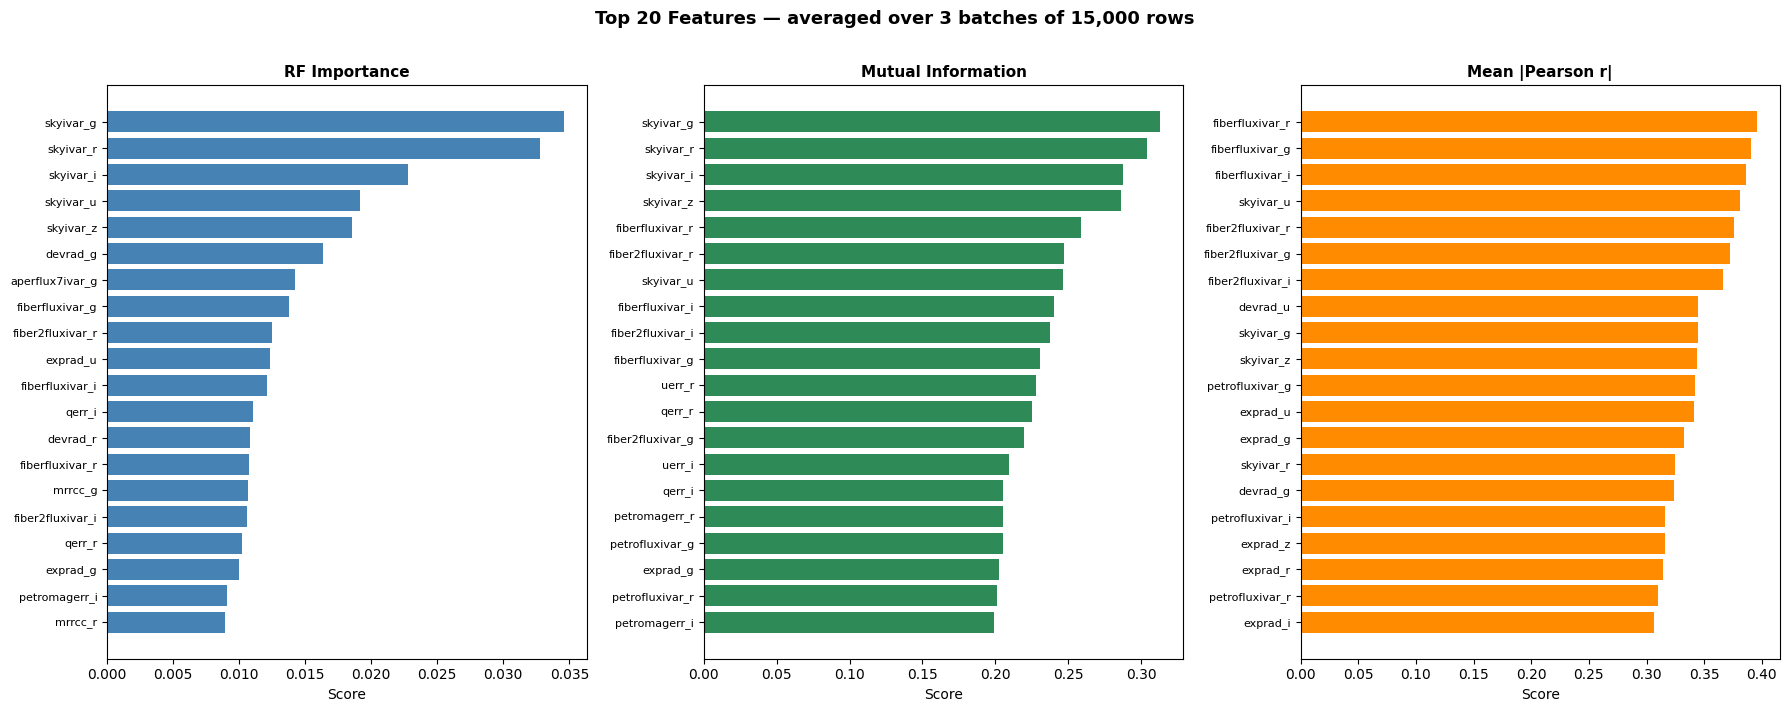

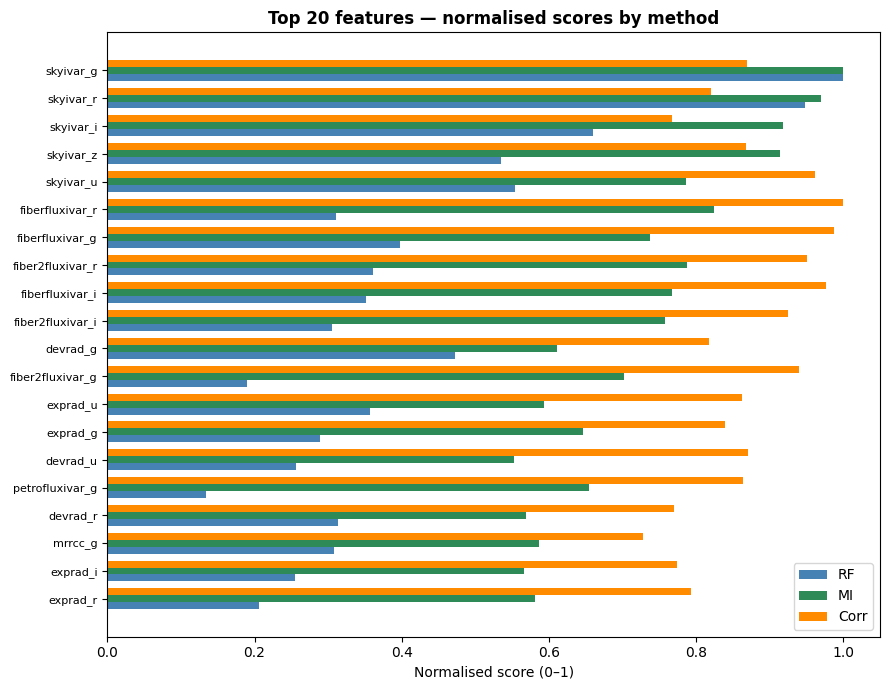

In [13]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

# ── Tuning knobs  (fastest = low N_BATCHES + small BATCH_SIZE + few trees) ──
TOP_N      = 20
N_BATCHES  = 3        # increase for more stable rankings (3–5 is plenty)
BATCH_SIZE = 15_000   # rows per batch — keeps each batch ~30 MB float32
RF_TREES   = 50       # trees per batch; 3 × 50 = 150 effective trees total

LABEL_COLS = ["galaxy_class_elliptical", "galaxy_class_merger", "galaxy_class_spiral"]
label_map  = {"galaxy_class_elliptical": 0, "galaxy_class_merger": 1, "galaxy_class_spiral": 2}

# ── Feature list & labels ─────────────────────────────────────────────
feature_cols_all = [c for c in df_clean.columns if c not in LABEL_COLS]
y_full = df_clean[LABEL_COLS].idxmax(axis=1).map(label_map).astype(np.int8).values

N, F = len(df_clean), len(feature_cols_all)
print(f"Dataset        : {N:,} rows  ×  {F} features")
print(f"Class counts   : { {k: int((y_full == v).sum()) for k, v in label_map.items()} }")
print(f"Batch config   : {N_BATCHES} batches  ×  {BATCH_SIZE:,} rows  |  {RF_TREES} RF trees/batch")
print(f"Memory/batch   : ~{BATCH_SIZE * F * 4 / 1e6:.0f} MB (float32)\n")

# ── Pre-compute per-column medians ONE COLUMN AT A TIME (no big alloc) ──
print("Computing column medians for NaN fill … ", end="", flush=True)
col_medians = pd.Series(
    {c: df_clean[c].median() for c in feature_cols_all}   # iterates 1 col at a time
)
print("done\n")

def make_batch(idx: np.ndarray) -> np.ndarray:
    """Slice rows first (cheap), then columns, fill NaNs, return float32."""
    chunk = df_clean.iloc[idx][feature_cols_all]   # rows first → small slice
    chunk = chunk.fillna(col_medians)
    return chunk.to_numpy(dtype=np.float32)

# ── Accumulators ──────────────────────────────────────────────────────
rf_accum   = np.zeros(F, dtype=np.float64)
mi_accum   = np.zeros(F, dtype=np.float64)
corr_accum = np.zeros((F, len(LABEL_COLS)), dtype=np.float64)

rng = np.random.default_rng(42)

for b in range(N_BATCHES):
    # Stratified draw — equal rows per class
    idx = []
    per_class = BATCH_SIZE // len(label_map)
    for cls_val in label_map.values():
        cls_idx = np.where(y_full == cls_val)[0]
        chosen  = rng.choice(cls_idx, size=min(per_class, len(cls_idx)), replace=False)
        idx.extend(chosen.tolist())
    idx = np.array(idx, dtype=np.intp)
    rng.shuffle(idx)

    X_b = make_batch(idx)
    y_b = y_full[idx]

    print(f"── Batch {b + 1}/{N_BATCHES}  ({len(idx):,} rows, {X_b.nbytes / 1e6:.0f} MB) ──")

    # RF
    rf = RandomForestClassifier(
        n_estimators=RF_TREES,
        max_features="sqrt",
        n_jobs=-1,
        random_state=b,
        class_weight="balanced",
    )
    rf.fit(X_b, y_b)
    rf_accum += rf.feature_importances_
    print(f"  RF   done")

    # MI
    mi = mutual_info_classif(X_b, y_b, discrete_features=False, random_state=b)
    mi_accum += mi
    print(f"  MI   done")

    # Pearson |r| per class label — vectorised numpy, no pandas overhead
    for j, label in enumerate(LABEL_COLS):
        binary = (y_b == label_map[label]).astype(np.float32)
        Xc    = X_b - X_b.mean(axis=0)
        yc    = binary - binary.mean()
        numer = Xc.T @ yc
        denom = np.linalg.norm(Xc, axis=0) * np.linalg.norm(yc)
        with np.errstate(invalid="ignore", divide="ignore"):
            r = np.where(denom > 0, numer / denom, 0.0)
        corr_accum[:, j] += np.abs(r)
    print(f"  Corr done")
    del X_b  # free batch memory immediately

print(f"\nAll {N_BATCHES} batches complete — averaging …\n")

# ── Average across batches ────────────────────────────────────────────
rf_imp   = pd.Series(rf_accum   / N_BATCHES, index=feature_cols_all, name="rf_importance")
mi_imp   = pd.Series(mi_accum   / N_BATCHES, index=feature_cols_all, name="mi_score")
corr_imp = pd.Series(
    (corr_accum / N_BATCHES).mean(axis=1),
    index=feature_cols_all, name="mean_abs_corr",
)

rf_imp   = rf_imp.sort_values(ascending=False)
mi_imp   = mi_imp.sort_values(ascending=False)
corr_imp = corr_imp.sort_values(ascending=False)

rf_rank   = rf_imp.rank(ascending=False).rename("rf_rank")
mi_rank   = mi_imp.rank(ascending=False).rename("mi_rank")
corr_rank = corr_imp.rank(ascending=False).rename("corr_rank")

# ════════════════════════════════════════════════════════════════════════
# 10.1  RF
# ════════════════════════════════════════════════════════════════════════
print("═" * 60)
print(f"  10.1  Random Forest  (avg over {N_BATCHES} batches × {RF_TREES} trees)")
print("═" * 60)
display(rf_imp.head(TOP_N).reset_index()
        .rename(columns={"index": "feature"}).set_index("feature").round(6))

# ════════════════════════════════════════════════════════════════════════
# 10.2  MI
# ════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print(f"  10.2  Mutual Information  (avg over {N_BATCHES} batches)")
print("═" * 60)
display(mi_imp.head(TOP_N).reset_index()
        .rename(columns={"index": "feature"}).set_index("feature").round(6))

# ════════════════════════════════════════════════════════════════════════
# 10.3  PEARSON
# ════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print(f"  10.3  Mean |Pearson r|  (avg over {N_BATCHES} batches)")
print("═" * 60)
display(corr_imp.head(TOP_N).reset_index()
        .rename(columns={"index": "feature"}).set_index("feature").round(6))

# ════════════════════════════════════════════════════════════════════════
# 10.4  COMBINED RANK  &  TOP 20 SELECTION
# ════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print("  10.4  Combined Rank  (mean of RF, MI, Corr ranks)")
print("═" * 60)

combined = pd.concat([rf_imp, rf_rank, mi_imp, mi_rank, corr_imp, corr_rank], axis=1)
combined["combined_rank"] = combined[["rf_rank", "mi_rank", "corr_rank"]].mean(axis=1)
combined = combined.sort_values("combined_rank")

top20 = combined.head(TOP_N).copy()
top20.index.name = "feature"
display(top20.round(6))

feature_cols = top20.index.tolist()
print(f"\n  feature_cols  ({len(feature_cols)} features):")
for i, f in enumerate(feature_cols, 1):
    print(f"    {i:>2}. {f}")

# ════════════════════════════════════════════════════════════════════════
# 10.5  VISUALISATION
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

datasets = [
    (rf_imp.head(TOP_N),   "RF Importance",     "steelblue"),
    (mi_imp.head(TOP_N),   "Mutual Information", "seagreen"),
    (corr_imp.head(TOP_N), "Mean |Pearson r|",   "darkorange"),
]

for ax, (series, title, colour) in zip(axes, datasets):
    vals = series.sort_values(ascending=True)
    ax.barh(vals.index, vals.values, color=colour)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Score")
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle(
    f"Top {TOP_N} Features — averaged over {N_BATCHES} batches of {BATCH_SIZE:,} rows",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

# ── Combined normalised scores ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
norm_rf   = (rf_imp[feature_cols]   / rf_imp.max()).rename("RF")
norm_mi   = (mi_imp[feature_cols]   / mi_imp.max()).rename("MI")
norm_corr = (corr_imp[feature_cols] / corr_imp.max()).rename("Corr")

combo_norm = pd.concat([norm_rf, norm_mi, norm_corr], axis=1)
combo_norm["mean"] = combo_norm.mean(axis=1)
combo_norm = combo_norm.sort_values("mean", ascending=True)

bar_h = 0.25
y_pos = np.arange(len(combo_norm))
ax.barh(y_pos - bar_h, combo_norm["RF"],   bar_h, label="RF",   color="steelblue",  align="center")
ax.barh(y_pos,         combo_norm["MI"],   bar_h, label="MI",   color="seagreen",   align="center")
ax.barh(y_pos + bar_h, combo_norm["Corr"], bar_h, label="Corr", color="darkorange", align="center")
ax.set_yticks(y_pos)
ax.set_yticklabels(combo_norm.index, fontsize=8)
ax.set_xlabel("Normalised score (0–1)")
ax.set_title(f"Top {TOP_N} features — normalised scores by method", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


In [15]:
combined.to_csv(RESULTS_DIR / "feature_importance_combined.csv")